In [1]:
# Import necessary libraries
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Function to extract loss values from log lines
def extract_loss(log_lines):
    losses = []
    for line in log_lines:
        # Use regex to find the loss value in the line
        match = re.search(r'Train Epoch: \d+ \d+ ([\d.]+)', line)
        if match:
            loss = float(match.group(1))
            losses.append(loss)
    return losses

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [7]:
# Function to read log file and extract loss values
def read_log_file(file_path):
    with open(file_path, 'r') as file:
        log_lines = file.readlines()
    return np.array(extract_loss(log_lines))

log_file_path = 'vit_2_par.out' 
loss_serial = read_log_file(log_file_path)

log_file_path = 'vit_2_par-parallel-only.out' 
loss_parallel = read_log_file(log_file_path)

offset = 6000
skip = 100
log_file_path = 'vit-cont.out'
loss_continue_22 = read_log_file(log_file_path)
p_and_s = np.concat((loss_parallel[0:offset], loss_continue_22[skip:]))

downsample_factor = 50
batches = np.arange(len(loss_serial))
loss_serial_batches = batches[::downsample_factor]
loss_serial_downsampled = loss_serial[::downsample_factor]

batches = np.arange(len(loss_parallel))
loss_parallel_batches = batches[::downsample_factor]
loss_parallel_downsampled = loss_parallel[::downsample_factor]

batches = np.arange(len(p_and_s))
p_and_s_batches = batches[::downsample_factor]
p_and_s_downsampled = p_and_s[::downsample_factor]

# Export loss_serial to CSV
loss_serial_data = np.column_stack((loss_serial_batches, loss_serial_downsampled))
np.savetxt("loss_serial_vit.csv", loss_serial_data, delimiter=",", header="Batches,loss_serial", comments="")

loss_parallel_data = np.column_stack((loss_parallel_batches, loss_parallel_downsampled))
np.savetxt("loss_parallel_vit.csv", loss_parallel_data, delimiter=",", header="Batches,loss_parallel", comments="")

p_and_s_data = np.column_stack((p_and_s_batches, p_and_s_downsampled))
np.savetxt("p_and_s_vit.csv", p_and_s_data, delimiter=",", header="Batches,p_and_s", comments="")



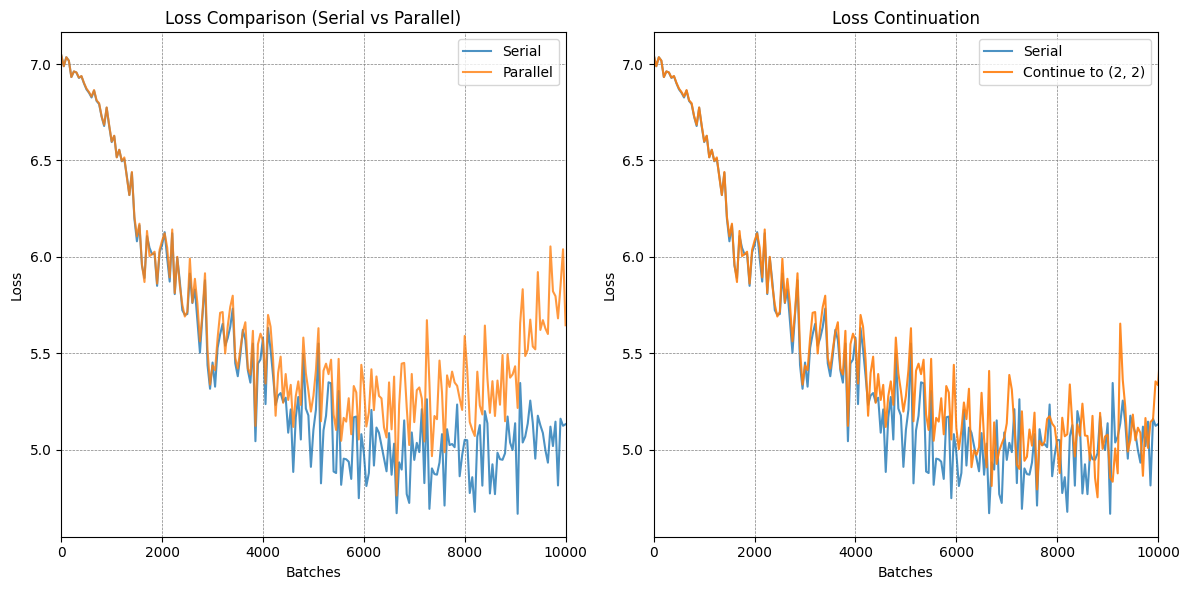

In [8]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot on the left side (axes[0])
axes[0].plot(loss_serial_batches, loss_serial_downsampled, alpha=0.8)
axes[0].plot(loss_parallel_batches, loss_parallel_downsampled, alpha=0.8)
axes[0].set_title('Loss Comparison (Serial vs Parallel)')
axes[0].set_xlabel('Batches')
axes[0].set_ylabel('Loss')
axes[0].legend(['Serial', 'Parallel'])
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)
axes[0].set_xlim(0, 10000)


# Plot on the right side (axes[1])
# First create right side data
axes[1].plot(loss_serial_batches, loss_serial_downsampled, alpha=0.8)
axes[1].plot(p_and_s_batches,p_and_s_downsampled, alpha=0.9)
axes[1].set_title('Loss Continuation')
axes[1].set_xlabel('Batches')
axes[1].set_ylabel('Loss')
axes[1].legend(['Serial', 'Continue to (2, 2)'])
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)
axes[1].set_xlim(0, 10000)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


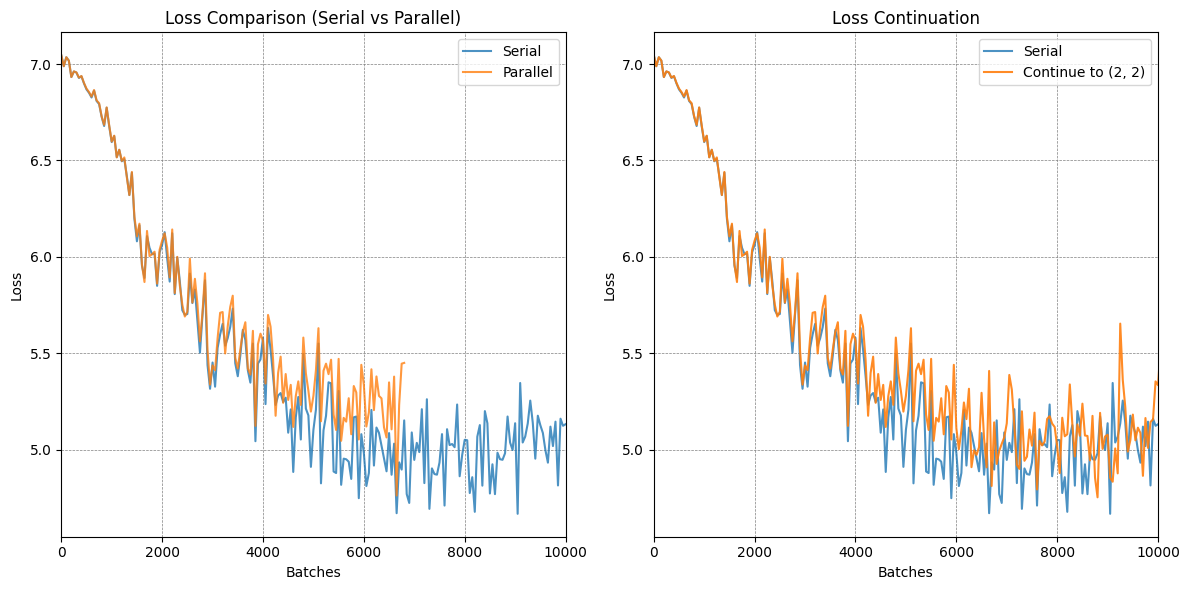

In [14]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot on the left side (axes[0])
axes[0].plot(loss_serial_batches, loss_serial_downsampled, alpha=0.8)
axes[0].plot(loss_parallel_batches, loss_parallel_downsampled, alpha=0.8)
axes[0].set_title('Loss Comparison (Serial vs Parallel)')
axes[0].set_xlabel('Batches')
axes[0].set_ylabel('Loss')
axes[0].legend(['Serial', 'Parallel'])
axes[0].grid(color='gray', linestyle='--', linewidth=0.5)
axes[0].set_xlim(0, 10000)


# Plot on the right side (axes[1])
# First create right side data
axes[1].plot(loss_serial_batches, loss_serial_downsampled, alpha=0.8)
axes[1].plot(p_and_s_batches,p_and_s_downsampled, alpha=0.9)
axes[1].set_title('Loss Continuation')
axes[1].set_xlabel('Batches')
axes[1].set_ylabel('Loss')
axes[1].legend(['Serial', 'Continue to (2, 2)'])
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)
axes[1].set_xlim(0, 10000)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


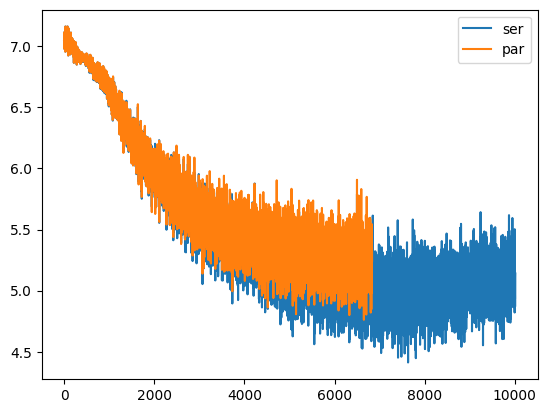

In [4]:
plt.plot(loss_1)
plt.plot(loss_2)
plt.legend(['ser', 'par'])
plt.show()